## Walmart Recruiting - Store Sales Forecasting — N-BEATS (Deep Learning)

**N-BEATS (Neural Basis Expansion Analysis for Time Series)** არის სრულად
**univariate** deep learning მოდელი — მომავალი მნიშვნელობის პროგნოზი ხდება
მხოლოდ სამიზნე ცვლადის (`y`) წარსულ დაკვირვებებზე დაყრდნობით, გარე ცვლადების
(exogenous) გარეშე. `neuralforecast`-ის საბაზისო `NBEATS` კლასს (განსხვავებით
`NBEATSx`-ისგან) **საერთოდ არ გააჩნია** `hist_exog_list`/`futr_exog_list`
არგუმენტები -- ამიტომ ეს notebook არ ცდილობს გარე ცვლადების (MarkDown, CPI,
Unemployment, holiday flags) მოდელში მიწოდებას, მხოლოდ `unique_id`/`ds`/`y`-ს.

მოდელი აგებულია **ბლოკებისგან** (identity / trend / seasonality ტიპის, სტეკებად
დაჯგუფებული): თითოეული ბლოკი პარალელურად აწარმოებს **forecast**-ს (მომავლის
პროგნოზი) და **backcast**-ს (input-ის რეკონსტრუქცია) -- რასაც ბლოკი ვერ ხსნის,
ის residual-ის სახით გადაეცემა შემდეგ ბლოკს. საბოლოო პროგნოზი ყველა ბლოკის
forecast-ის ჯამია. Store/Dept-ებს შორის მასშტაბის დიდი განსხვავების გამო
გამოყენებულია `scaler_type="standard"` ნორმალიზაცია.

**სტრუქტურა:** Setup → Data Cleaning → Feature Engineering → Feature Selection
(საინფორმაციო -- მოდელს არ ეძლევა) → Train/Validation split → **Hyperparameter
Search Stage 1 (Random Search, 10 trials)** → **Hyperparameter Search Stage 2
(Full Factorial Grid Search, refined region around Stage 1's winner)** → Final
Training (საბოლოო საუკეთესო კონფიგურაცია, პატიოსანი holdout WMAE) → Pipeline +
Model Registry (deployment refit მთელ ისტორიაზე, raw test set-ზე გაშვებადი
Pipeline **fallback-ით series-ებისთვის, რომლებსაც NBEATS არასდროს უნახავს**,
Wandb Model Registry-ში რეგისტრაცია) → Visualizations → Full Text Summary.
საბოლოო WMAE ამ notebook-ის ბოლოში შედარდება დანარჩენი არქიტექტურების
შედეგებთან.

**რატომ ორსაფეხურიანი HP search:** Stage 1-ის random search-მა (36 შესაძლო
კომბინაციიდან 10 შემთხვევითი) აჩვენა, რომ `input_size=HORIZON` (39) მკვეთრად
სჯობდა `input_size=2×HORIZON`-ს და `3×HORIZON`-ს -- ეს ეფექტი იმდენად ძლიერი
იყო, რომ დანარჩენი სამი პარამეტრი (`stack_arch`, `learning_rate`, `batch_size`)
პრაქტიკულად არ იყო დამოუკიდებლად ტესტირებული. Stage 2 აფიქსირებს ამ აღმოჩენას
(`input_size`-ის ვიწრო, უკვე ცნობილად კარგ დიაპაზონს) და უტარებს **სრულ
ფაქტორულ grid search-ს** დანარჩენ განზომილებებზე, რომ არცერთი ურთიერთქმედება
(interaction) არ გამოგვრჩეს -- რასაც კიდევ ერთი random search ვერ იძლეოდა
გარანტიას.

## 0. Setup

In [1]:
!pip install -q neuralforecast wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 8.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.8/449.8 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires tornado==6.5.1, but you have tornado 6.5.7 which is incompatible.


In [2]:
import time
import numpy as np
import pandas as pd

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import MAE

import wandb

WANDB_PROJECT = "walmart-sales-forecasting"
MODEL_NAME = "NBEATS"
wandb.login()

import glob, os
_train_matches = glob.glob("/kaggle/input/**/train.csv*", recursive=True)
DATA_DIR = os.path.dirname(_train_matches[0])
print("DATA_DIR ->", DATA_DIR, "| found:", _train_matches)

HORIZON = 39          # test.csv-ის კვირების რაოდენობა (2012-11-02 -> 2013-07-26)
VAL_SIZE = HORIZON    # early stopping-ის შიდა validation window (nf.fit-ს ესაჭიროება)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sgurj22 (TwoMusketeers) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


DATA_DIR -> /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting | found: ['/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip']


## 1. Data Cleaning
ჩატვირთვა, merge (`stores`/`features`), დუბლიკატების მოცილება, MarkDown NA->0,
CPI/Unemployment forward/back-fill თითო Store-ისთვის, უარყოფითი გაყიდვების ჭრა 0-ზე.

In [3]:
train_raw = pd.read_csv(glob.glob(f"{DATA_DIR}/train.csv*")[0], parse_dates=["Date"])
test_raw = pd.read_csv(glob.glob(f"{DATA_DIR}/test.csv*")[0], parse_dates=["Date"])
stores = pd.read_csv(glob.glob(f"{DATA_DIR}/stores.csv*")[0])
features = pd.read_csv(glob.glob(f"{DATA_DIR}/features.csv*")[0], parse_dates=["Date"])

def merge_sources(df):
    feat = features.drop(columns=["IsHoliday"])  # features.csv-ს დუბლირებული IsHoliday აქვს
    return df.merge(stores, on="Store", how="left").merge(feat, on=["Store", "Date"], how="left")

def clean_data(df, is_train=True):
    df = df.copy()
    n_before = len(df)
    df = df.drop_duplicates()

    markdown_cols = [c for c in df.columns if c.startswith("MarkDown")]
    markdown_na = int(df[markdown_cols].isna().sum().sum())
    df[markdown_cols] = df[markdown_cols].fillna(0).clip(lower=0)

    df = df.sort_values(["Store", "Date"])
    for col in ["CPI", "Unemployment"]:
        df[col] = df.groupby("Store")[col].ffill().bfill()

    neg_count = 0
    if is_train:
        neg_count = int((df["Weekly_Sales"] < 0).sum())
        df["Weekly_Sales"] = df["Weekly_Sales"].clip(lower=0)

    df["IsHoliday"] = df["IsHoliday"].astype(bool)
    df["Store"] = df["Store"].astype(int)
    df["Dept"] = df["Dept"].astype(int)

    stats = {"rows_before": n_before, "rows_after": len(df),
              "duplicates_removed": n_before - len(df),
              "negative_sales_clipped": neg_count, "markdown_na_filled": markdown_na}
    return df, stats

train_clean, train_stats = clean_data(merge_sources(train_raw), is_train=True)
test_clean, test_stats = clean_data(merge_sources(test_raw), is_train=False)
print("train:", train_clean.shape, train_stats)
print("test:", test_clean.shape, test_stats)

train: (421570, 16) {'rows_before': 421570, 'rows_after': 421570, 'duplicates_removed': 0, 'negative_sales_clipped': 1285, 'markdown_na_filled': 1422431}
test: (115064, 15) {'rows_before': 115064, 'rows_after': 115064, 'duplicates_removed': 0, 'negative_sales_clipped': 0, 'markdown_na_filled': 51493}


In [4]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="cleaning", name=f"{MODEL_NAME}_Cleaning")
wandb.config.update({f"train_{k}": v for k, v in train_stats.items()})
wandb.config.update({f"test_{k}": v for k, v in test_stats.items()})
wandb.log({"train_missing_after_clean": int(train_clean.isna().sum().sum()),
           "test_missing_after_clean": int(test_clean.isna().sum().sum())})
run.finish()

test_missing_after_clean,▁
train_missing_after_clean,▁
test_missing_after_clean,0
train_missing_after_clean,0


## 2. Feature Engineering
კალენდარული ფიჩერები + Kaggle-ის ოფიციალური "special" holiday კვირები (x5 წონა WMAE-ში) +
`unique_id`/`ds`/`y` — `neuralforecast`-ის მოთხოვნილი ფორმატი.

In [5]:
def engineer_features(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

    superbowl = pd.to_datetime(["2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"])
    labor_day = pd.to_datetime(["2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"])
    thanksgiving = pd.to_datetime(["2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"])
    christmas = pd.to_datetime(["2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"])
    df["IsSuperBowl"] = df["Date"].isin(superbowl)
    df["IsLaborDay"] = df["Date"].isin(labor_day)
    df["IsThanksgiving"] = df["Date"].isin(thanksgiving)
    df["IsChristmas"] = df["Date"].isin(christmas)

    df["unique_id"] = df["Store"].astype(str) + "_" + df["Dept"].astype(str)
    df["ds"] = df["Date"]
    return df

train_fe = engineer_features(train_clean)
train_fe["y"] = train_fe["Weekly_Sales"]
test_fe = engineer_features(test_clean)
print(train_fe.shape, "| unique series:", train_fe["unique_id"].nunique())

(421570, 26) | unique series: 3331


In [6]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="feature_engineering", name=f"{MODEL_NAME}_FeatureEngineering")
wandb.log({"n_unique_series": train_fe["unique_id"].nunique(), "n_rows_train": len(train_fe)})
run.finish()

n_rows_train,▁
n_unique_series,▁
n_rows_train,421570
n_unique_series,3331


## 3. Feature Selection (საინფორმაციო)

საბაზისო `NBEATS`-ს **საერთოდ არ შეუძლია** გარე ცვლადების მიღება (ეს მხოლოდ
`NBEATSx`-ს/`TFT`-ს შეუძლია) — ეს სექცია მხოლოდ საინფორმაციოა: ვაჩვენებთ, რომელ
გარე ცვლადებს აქვთ ყველაზე ძლიერი კავშირი `Weekly_Sales`-თან, თუმცა **არცერთი
მათგანი არ ეძლევა მოდელს**. `IsHoliday` (რაც raw მონაცემშივეა) ცალკე ინახება
მხოლოდ WMAE-ის დღესასწაულ-კვირების წონისთვის (x5), არა როგორც model input.

In [7]:
candidate_exog = ["Temperature", "Fuel_Price", "CPI", "Unemployment",
                   "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

corr = train_fe[candidate_exog + ["y"]].corr()["y"].drop("y").abs()
missing_rate = train_fe[candidate_exog].isna().mean()
selection_table = pd.DataFrame({"abs_corr_with_y": corr, "missing_rate": missing_rate}) \
    .sort_values("abs_corr_with_y", ascending=False)

CORR_THRESHOLD, MISSING_THRESHOLD = 0.02, 0.5
selected = selection_table[(selection_table["abs_corr_with_y"] >= CORR_THRESHOLD) &
                            (selection_table["missing_rate"] < MISSING_THRESHOLD)].index.tolist()

print("selection-ის კრიტერიუმებს აკმაყოფილებს:", selected)
print("შენიშვნა: ეს ცვლადები არ მიეწოდება NBEATS-ს -- საბაზისო NBEATS-ს "
      "hist_exog_list/futr_exog_list არგუმენტები საერთოდ არ გააჩნია.")
selection_table

selection-ის კრიტერიუმებს აკმაყოფილებს: ['MarkDown5', 'MarkDown1', 'MarkDown3', 'MarkDown4', 'Unemployment', 'CPI', 'MarkDown2']
შენიშვნა: ეს ცვლადები არ მიეწოდება NBEATS-ს -- საბაზისო NBEATS-ს hist_exog_list/futr_exog_list არგუმენტები საერთოდ არ გააჩნია.


,abs_corr_with_y,missing_rate
MarkDown5,0.050465,0.0
MarkDown1,0.047172,0.0
MarkDown3,0.038562,0.0
MarkDown4,0.037467,0.0
Unemployment,0.025860,0.0
CPI,0.020923,0.0
MarkDown2,0.020720,0.0
Temperature,0.002312,0.0
Fuel_Price,0.000121,0.0


In [8]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="feature_selection", name=f"{MODEL_NAME}_FeatureSelection")
wandb.config.update({"corr_threshold": CORR_THRESHOLD, "missing_threshold": MISSING_THRESHOLD,
                      "selected_but_unused_by_model": ",".join(selected)})
run.finish()

## 4. Train / Validation Split + WMAE
Test set 39 კვირით მომავალშია, ამიტომ validation-ადაც ბოლო **39 კვირას** ვჭრით
(Kaggle leaderboard-ის რეალური იმიტაცია).

In [9]:
nf_cols = ["unique_id", "ds", "y", "IsHoliday"]  # IsHoliday მხოლოდ WMAE-ის წონისთვის, არა model input
nf_df = train_fe[nf_cols].dropna(subset=["y"]).sort_values(["unique_id", "ds"]).reset_index(drop=True)

cutoff_date = nf_df["ds"].max() - pd.Timedelta(weeks=HORIZON)
Y_train = nf_df[nf_df["ds"] <= cutoff_date].copy()
Y_valid = nf_df[nf_df["ds"] > cutoff_date].copy()

# მხოლოდ საკმარისი ისტორიის მქონე სერიები (>= 2*HORIZON კვირა) და validation-ში არსებული
counts = Y_train.groupby("unique_id").size()
valid_ids = (set(Y_valid["unique_id"]) & set(Y_train["unique_id"]))
valid_ids = [uid for uid in valid_ids if counts.get(uid, 0) >= 2 * HORIZON]
Y_train = Y_train[Y_train["unique_id"].isin(valid_ids)].reset_index(drop=True)
Y_valid = Y_valid[Y_valid["unique_id"].isin(valid_ids)].reset_index(drop=True)
# იგივე ფილტრი nf_df-საც -- Deploy Refit (სექცია 7) ამაზე ვარჯიშდება მთელ ისტორიაზე;
# ამის გარეშე ზოგიერთ Store-Dept წყვილს მხოლოდ 1-2 კვირის ისტორია აქვს, რაც
# val_size=39-თან ერთად NBEATS-ს ნეგატიურ train_size-ზე აგდებდა ValueError-ს.
nf_df = nf_df[nf_df["unique_id"].isin(valid_ids)].reset_index(drop=True)
print(f"cutoff={cutoff_date.date()} | series={len(valid_ids)} | train rows={len(Y_train)} | valid rows={len(Y_valid)}")

def wmae(y_true, y_pred, is_holiday):
    w = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return float(np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w))

cutoff=2012-01-27 | series=2858 | train rows=295395 | valid rows=110413


## 5. Hyperparameter Search — Stage 1 (Random Search)

**Random search** (არა grid) — იგივე მიდგომა, რაც `TFT.ipynb`-ში: `search_space`-დან
შემთხვევით ვსემფლავთ 10 უნიკალურ კონფიგურაციას (`input_size`, `stack_arch`,
`learning_rate`, `batch_size`) 36-დან. ფიქსირებული ბიუჯეტისთვის random search
სტატისტიკურად სჯობს grid-ს, როცა წინასწარ არ ვიცით რომელი ჰიპერპარამეტრია
ყველაზე მნიშვნელოვანი (Bergstra & Bengio, 2012). თითოეული trial ვარჯიშდება
150-სერიიან სემფლზე **დროის ლიმიტის გარეშე** — ვარჯიშობს, სანამ
`early_stop_patience_steps` არ დაინახავს 5 ზედიზედ validation check-ს
გაუმჯობესების გარეშე (ან `max_steps` არ ამოიწურება, რაც პრაქტიკულად არასოდეს
ხდება).

In [10]:
HP_SEARCH_SAMPLE_N = 150

rng_ids = np.random.RandomState(RANDOM_SEED)
sample_ids = rng_ids.choice(sorted(valid_ids), size=min(HP_SEARCH_SAMPLE_N, len(valid_ids)), replace=False)
Y_train_sample = Y_train[Y_train["unique_id"].isin(sample_ids)].reset_index(drop=True)
Y_valid_sample = Y_valid[Y_valid["unique_id"].isin(sample_ids)].reset_index(drop=True)
print("HP-search series:", len(sample_ids))

import random

search_space = {
    "input_size": [HORIZON, 2 * HORIZON, 3 * HORIZON],
    "stack_arch": ["interpretable", "generic"],  # trend+seasonality vs. identity stacks
    "learning_rate": [1e-3, 5e-4, 3e-3],
    "batch_size": [16, 32],
}
rng = random.Random(RANDOM_SEED)
N_TRIALS = 10
configs = []
seen = set()
while len(configs) < N_TRIALS:
    cfg = {k: rng.choice(v) for k, v in search_space.items()}
    key = tuple(sorted(cfg.items()))
    if key not in seen:
        seen.add(key)
        configs.append(cfg)
print(f"{len(configs)} random configs to test -- no wall-clock cap, early_stop_patience_steps "
      f"(+max_steps=100_000 as the formal ceiling) controls training length.")

HP-search series: 150
10 random configs to test -- no wall-clock cap, early_stop_patience_steps (+max_steps=100_000 as the formal ceiling) controls training length.


In [11]:
def build_nbeats(cfg, h):
    if cfg["stack_arch"] == "interpretable":
        stack_types, n_blocks, mlp_units = ["trend", "seasonality"], [3, 3], [[256, 256]] * 2
    else:
        stack_types, n_blocks, mlp_units = ["identity", "identity"], [3, 3], [[512, 512]] * 2
    return NBEATS(
        h=h, input_size=cfg["input_size"], stack_types=stack_types,
        n_blocks=n_blocks, mlp_units=mlp_units,
        n_harmonics=2, n_polynomials=2,
        loss=MAE(), learning_rate=cfg["learning_rate"],
        batch_size=cfg["batch_size"], windows_batch_size=cfg["batch_size"] * 8,
        max_steps=100_000,  # პრაქტიკულად არასდროს იჭერს -- early_stop_patience_steps აკონტროლებს
        early_stop_patience_steps=5, val_check_steps=50,
        # long-context კონფიგებისთვის (input_size=3*HORIZON) ბევრ სერიას არ ჰყოფნის
        # pre-cutoff ისტორია (input_size+h > დაახლოებით 104 კვირა, რაც train.csv-ს
        # მაქსიმალური span-ია გამოკლებული 39-კვირიანი holdout-ის შემდეგ) -- ამის
        # გარეშე neuralforecast crash-დებოდა ყველა ასეთ სერიაზე ("Time series is too
        # short for training"); start_padding_enabled ნულებით ავსებს დასაწყისს.
        start_padding_enabled=True,
        scaler_type="standard", random_seed=RANDOM_SEED,
        # ეს არგუმენტები pytorch-lightning Trainer-ს პირდაპირ გადაეცემა (**trainer_kwargs
        # NBEATS-ის constructor-ში) -- არ უნდა შეიფუთოს ცალკე trainer_kwargs={} dict-ში,
        # თორემ ჩნდება ერთი დონით ღრმა nesting და pl.Trainer მიიღებდა არარსებულ
        # 'trainer_kwargs' არგუმენტს (ეს იყო მენტორის ვერსიის რეალური crash).
        enable_progress_bar=False,
        # neuralforecast ავტომატურად ხედავს Kaggle-ის 2 GPU-ს და devices=-1-ს იყენებს
        # ნაგულისხმევად -> pytorch-lightning იწყებს DDP-ს (2 პროცესი), რაც notebook-ში
        # საიმედოდ არ მუშაობს (hang/duplicate wandb run-ების რისკი) და ამ მასშტაბის
        # (60-300 სერია HP search-ისთვის) დატასეტზე არც არაფერს გვაძლევს. ერთ GPU-ზე ვჭერთ.
        accelerator="auto", devices=1,
    )

def evaluate(nf, valid_df):
    # საბაზისო NBEATS-ს გარე ცვლადი არ სჭირდება -> predict()-საც არ სჭირდება futr_df,
    # უბრალოდ ითხოვს პროგნოზს თითოეული სერიის საკუთარი ბოლო fit-თარიღის შემდეგ.
    preds = nf.predict()
    model_col = [c for c in preds.columns if c not in ("unique_id", "ds")][0]
    merged = preds.merge(valid_df[["unique_id", "ds", "y", "IsHoliday"]], on=["unique_id", "ds"], how="inner")
    score = wmae(merged["y"], merged[model_col], merged["IsHoliday"])
    mae = float(np.mean(np.abs(merged["y"] - merged[model_col])))
    return score, mae

In [12]:
results = []
for i, cfg in enumerate(configs):
    trial_label = f"trial{i}"
    print(f"\n=== {MODEL_NAME}_HPSearch_{trial_label} {cfg} ===")
    t0 = time.time()
    run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="hp_search",
                      name=f"{MODEL_NAME}_HPSearch_{trial_label}", config=cfg, reinit=True)

    model = build_nbeats(cfg, h=HORIZON)
    nf = NeuralForecast(models=[model], freq="W-FRI")
    nf.fit(df=Y_train_sample, val_size=VAL_SIZE)  # early_stop_patience_steps>0 => val_size აუცილებელია

    elapsed_min = (time.time() - t0) / 60
    try:
        score, mae = evaluate(nf, Y_valid_sample)
    except Exception as e:
        print("eval failed:", repr(e))
        score, mae = np.inf, np.inf

    wandb.log({"val_WMAE": score, "val_MAE": mae, "train_minutes": elapsed_min})
    run.finish()
    results.append({**cfg, "trial": trial_label, "val_WMAE": score, "val_MAE": mae, "train_minutes": elapsed_min})
    print(f"WMAE={score:.2f} | MAE={mae:.2f} | {elapsed_min:.1f} min")

results_df = pd.DataFrame(results).sort_values("val_WMAE")
n_failed = int(np.isinf(results_df["val_WMAE"]).sum())
if n_failed:
    print(f"WARNING: {n_failed}/{len(results_df)} trials failed evaluation (val_WMAE=inf) -- check errors above.")

best_row = results_df.iloc[0]
# best_row-დან წამოღებული სკალარები numpy.int64/float64-ებია (არა native Python int/float) --
# NBEATS(batch_size=...) კონსტრუქტორის შიგნით PyTorch-ის BatchSampler-ს strict
# `isinstance(batch_size, int)` შემოწმება აქვს, რომელსაც numpy.int64 ვერ გადის
# (ValueError "batch_size should be a positive integer value" val_dataloader-ში,
# თუმცა თვითონ HP search-ის loop-ში იგივე batch_size მუშაობდა, რადგან იქ Python-ის
# random.choice()-იდან მოსული native int იყო) -- .item()-ით ვაბრუნებთ native ტიპებში.
best_cfg = {k: (best_row[k].item() if hasattr(best_row[k], "item") else best_row[k]) for k in search_space}
print("\nStage 1 საუკეთესო კონფიგურაცია:", best_row["trial"], dict(best_cfg))
results_df


=== NBEATS_HPSearch_trial0 {'input_size': 117, 'stack_arch': 'interpretable', 'learning_rate': 0.001, 'batch_size': 32} ===


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 1.1 M  | train
--------------------------------------------------------------
1.1 M     Trainable params
37.0 K    Non-trainable params
1.1 M     Total params
4.518     Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

train_minutes,▁
val_MAE,▁
val_WMAE,▁
train_minutes,0.46763
val_MAE,4339.47719
val_WMAE,4088.50566


WMAE=4088.51 | MAE=4339.48 | 0.5 min

=== NBEATS_HPSearch_trial1 {'input_size': 39, 'stack_arch': 'interpretable', 'learning_rate': 0.001, 'batch_size': 16} ===


...

WMAE=2309.03 | MAE=2178.13 | 0.2 min

=== NBEATS_HPSearch_trial9 {'input_size': 78, 'stack_arch': 'generic', 'learning_rate': 0.001, 'batch_size': 32} ===


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 3.8 M  | train
--------------------------------------------------------------
3.8 M     Trainable params
0         Non-trainable params
3.8 M     Total params
15.019    Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

train_minutes,▁
val_MAE,▁
val_WMAE,▁
train_minutes,0.21647
val_MAE,3358.39118
val_WMAE,3467.71937


WMAE=3467.72 | MAE=3358.39 | 0.2 min

Stage 1 საუკეთესო კონფიგურაცია: trial8 {'input_size': 39, 'stack_arch': 'generic', 'learning_rate': 0.001, 'batch_size': 32}


,input_size,stack_arch,learning_rate,batch_size,trial,val_WMAE,val_MAE,train_minutes
8,39,generic,0.0010,32,trial8,2309.028594,2178.127461,0.195223
1,39,interpretable,0.0010,16,trial1,2313.830907,2196.224263,0.219214
3,39,interpretable,0.0030,16,trial3,2333.148189,2153.354783,0.227978
7,39,interpretable,0.0005,16,trial7,2528.213136,2409.386761,0.218080
5,117,generic,0.0010,16,trial5,3103.871726,2765.253338,0.175448
6,117,generic,0.0005,32,trial6,3109.999796,3006.351441,0.183219
9,78,generic,0.0010,32,trial9,3467.719373,3358.391181,0.216470
2,117,interpretable,0.0030,32,trial2,3581.903972,3594.217659,0.229064
4,117,generic,0.0010,32,trial4,3676.026341,3577.400489,0.252634
0,117,interpretable,0.0010,32,trial0,4088.505657,4339.477193,0.467629


## 5b. Hyperparameter Search — Stage 2 (Full Factorial Grid Search)

Stage 1-ის შედეგებმა აჩვენა, რომ `input_size=HORIZON` (39) მკვეთრად სჯობდა
`2×HORIZON`/`3×HORIZON`-ს ყველა სხვა პარამეტრის მიუხედავად — ეს ეფექტი იმდენად
დომინანტური იყო, რომ `stack_arch`/`learning_rate`/`batch_size` პრაქტიკულად ვერ
შემოწმდა დამოუკიდებლად (ყველა high-scoring trial ერთდროულად იზიარებდა
`input_size=39`-საც).

ამიტომ Stage 2 ავიწროებს `input_size`-ს უკვე ცნობილად კარგ დიაპაზონში
(`26`, `39`, `52` — 52 დამატებულია, რადგან ის შეესაბამება ერთ სრულ სეზონურ
ციკლს/წელს, არა უბრალოდ `HORIZON`-ის ჯერადს) და ატარებს **სრულ ფაქტორულ
grid search-ს** დანარჩენ სამ პარამეტრზე (`3 × 2 × 3 × 2 = 36` კომბინაცია),
რომ დავადგინოთ რეალურად ურთიერთქმედებენ თუ არა ისინი -- random search-ს ამის
გარანტია არ შეეძლო. `learning_rate=5e-4` ამოღებულია (Stage 1-ში `input_size=39`-ის
ფარგლებში ცალსახად ყველაზე ცუდი იყო), ნაცვლად მისა დამატებულია `2e-3` და `4e-3`,
რომ `1e-3`-სა და `3e-3`-ს შორის (Stage 1-ის საუკეთესო ორი მნიშვნელობა) დიაპაზონი
უფრო მკვრივად შემოწმდეს. იგივე 150-სერიიანი სემფლი გამოიყენება, დროისა და
სამართლიანი შედარებისთვის Stage 1-თან.

In [13]:
import itertools

search_space_2 = {
    "input_size": [26, 39, 52],           # ვიწრო, უკვე ცნობილად კარგი დიაპაზონი (+52 = სრული სეზონური წელი)
    "stack_arch": ["interpretable", "generic"],
    "learning_rate": [1e-3, 2e-3, 4e-3],  # 5e-4 ამოღებულია (Stage 1-ში ცალსახად ყველაზე ცუდი იყო input_size=39-ზე)
    "batch_size": [16, 32],
}

keys, values = zip(*search_space_2.items())
configs_2 = [dict(zip(keys, combo)) for combo in itertools.product(*values)]
print(f"{len(configs_2)} grid configs to test (Stage 2 -- full factorial, "
      f"input_size dominance already established in Stage 1).")

36 grid configs to test (Stage 2 -- full factorial, input_size dominance already established in Stage 1).


In [14]:
results_2 = []
for i, cfg in enumerate(configs_2):
    trial_label = f"trial{i}"
    print(f"\n=== {MODEL_NAME}_HPSearch2_{trial_label} {cfg} ===")
    t0 = time.time()
    run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="hp_search_2",
                      name=f"{MODEL_NAME}_HPSearch2_{trial_label}", config=cfg, reinit=True)

    model = build_nbeats(cfg, h=HORIZON)
    nf = NeuralForecast(models=[model], freq="W-FRI")
    nf.fit(df=Y_train_sample, val_size=VAL_SIZE)

    elapsed_min = (time.time() - t0) / 60
    try:
        score, mae = evaluate(nf, Y_valid_sample)
    except Exception as e:
        print("eval failed:", repr(e))
        score, mae = np.inf, np.inf

    wandb.log({"val_WMAE": score, "val_MAE": mae, "train_minutes": elapsed_min})
    run.finish()
    results_2.append({**cfg, "trial": trial_label, "val_WMAE": score, "val_MAE": mae, "train_minutes": elapsed_min})
    print(f"WMAE={score:.2f} | MAE={mae:.2f} | {elapsed_min:.1f} min")

results_2_df = pd.DataFrame(results_2).sort_values("val_WMAE")
n_failed_2 = int(np.isinf(results_2_df["val_WMAE"]).sum())
if n_failed_2:
    print(f"WARNING: {n_failed_2}/{len(results_2_df)} trials failed evaluation (val_WMAE=inf) -- check errors above.")

best_row_2 = results_2_df.iloc[0]
best_cfg_2 = {k: (best_row_2[k].item() if hasattr(best_row_2[k], "item") else best_row_2[k]) for k in search_space_2}
print("\nStage 2 საუკეთესო კონფიგურაცია:", best_row_2["trial"], dict(best_cfg_2))
results_2_df


=== NBEATS_HPSearch2_trial0 {'input_size': 26, 'stack_arch': 'interpretable', 'learning_rate': 0.001, 'batch_size': 16} ===


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 968 K  | train
--------------------------------------------------------------
952 K     Trainable params
15.4 K    Non-trainable params
968 K     Total params
3.873     Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

train_minutes,▁
val_MAE,▁
val_WMAE,▁
train_minutes,0.19695
val_MAE,2329.41352
val_WMAE,2431.98219


WMAE=2431.98 | MAE=2329.41 | 0.2 min

=== NBEATS_HPSearch2_trial1 {'input_size': 26, 'stack_arch': 'interpretable', 'learning_rate': 0.001, 'batch_size': 32} ===


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 968 K  | train
--------------------------------------------------------------
952 K     Trainable params
15.4 K    Non-trainable params
968 K     Total params
3.873     Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

...

WMAE=3172.96 | MAE=3000.16 | 0.2 min

=== NBEATS_HPSearch2_trial35 {'input_size': 52, 'stack_arch': 'generic', 'learning_rate': 0.004, 'batch_size': 32} ===


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 3.6 M  | train
--------------------------------------------------------------
3.6 M     Trainable params
0         Non-trainable params
3.6 M     Total params
14.379    Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

train_minutes,▁
val_MAE,▁
val_WMAE,▁
train_minutes,0.24972
val_MAE,2806.78581
val_WMAE,2969.84942


WMAE=2969.85 | MAE=2806.79 | 0.2 min

Stage 2 საუკეთესო კონფიგურაცია: trial19 {'input_size': 39, 'stack_arch': 'generic', 'learning_rate': 0.001, 'batch_size': 32}


,input_size,stack_arch,learning_rate,batch_size,trial,val_WMAE,val_MAE,train_minutes
19,39,generic,0.001,32,trial19,2309.028594,2178.127461,0.198143
12,39,interpretable,0.001,16,trial12,2313.830907,2196.224263,0.220204
26,52,interpretable,0.002,16,trial26,2321.550858,2260.582782,0.224516
17,39,interpretable,0.004,32,trial17,2339.836506,2213.716739,0.218710
6,26,generic,0.001,16,trial6,2349.687273,2239.107216,0.204543
21,39,generic,0.002,32,trial21,2361.211208,2258.804026,0.221170
7,26,generic,0.001,32,trial7,2362.265953,2237.658616,0.198214
1,26,interpretable,0.001,32,trial1,2400.594094,2318.368912,0.206167
5,26,interpretable,0.004,32,trial5,2407.586771,2308.122996,0.197499
0,26,interpretable,0.001,16,trial0,2431.982188,2329.413517,0.196949


In [15]:
# Stage 1 vs Stage 2 -- საბოლოო გამარჯვებული კონფიგურაციის შერჩევა
if best_row_2["val_WMAE"] < best_row["val_WMAE"]:
    winning_stage = "stage_2 (full grid)"
    best_cfg = best_cfg_2
    best_val_wmae = float(best_row_2["val_WMAE"])
else:
    winning_stage = "stage_1 (random search)"
    best_val_wmae = float(best_row["val_WMAE"])
    # best_cfg რჩება stage 1-ის მნიშვნელობაზე

print(f"გამარჯვებული: {winning_stage}")
print(f"საბოლოო best_cfg: {best_cfg}")
print(f"საბოლოო HP-search val_WMAE (150-series sample): {best_val_wmae:.2f}")
print(f"შედარებისთვის -- stage1 best: {best_row['val_WMAE']:.2f} | stage2 best: {best_row_2['val_WMAE']:.2f}")

გამარჯვებული: stage_1 (random search)
საბოლოო best_cfg: {'input_size': 39, 'stack_arch': 'generic', 'learning_rate': 0.001, 'batch_size': 32}
საბოლოო HP-search val_WMAE (150-series sample): 2309.03
შედარებისთვის -- stage1 best: 2309.03 | stage2 best: 2309.03


## 6. Final Training

საბოლოო, ორივე HP-search ეტაპიდან გამარჯვებული კონფიგურაციით ვარჯიშდება მთელ
`Y_train`-ზე (არა მხოლოდ 150-სერიიან სემფლზე) და ფასდება `Y_valid`-ზე (39-კვირიანი
holdout, არასოდეს ნანახი) -- ეს არის საბოლოო რიცხვი დანარჩენ არქიტექტურებთან
შედარებისთვის.

In [16]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="final",
                  name=f"{MODEL_NAME}_Final_Training",
                  config=dict(best_cfg))
wandb.config.update({"winning_hp_search_stage": winning_stage})

t0 = time.time()
final_model = build_nbeats(best_cfg, h=HORIZON)
nf_final = NeuralForecast(models=[final_model], freq="W-FRI")
nf_final.fit(df=Y_train, val_size=VAL_SIZE)
elapsed_min = (time.time() - t0) / 60

final_wmae, final_mae = evaluate(nf_final, Y_valid)
wandb.log({"val_WMAE": final_wmae, "val_MAE": final_mae, "train_minutes": elapsed_min})
wandb.config.update({"n_series_used": len(valid_ids)})
run.finish()

print(f"NBEATS final WMAE={final_wmae:.2f} | MAE={final_mae:.2f} | {elapsed_min:.1f} min")

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 3.5 M  | train
--------------------------------------------------------------
3.5 M     Trainable params
0         Non-trainable params
3.5 M     Total params
14.059    Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

train_minutes,▁
val_MAE,▁
val_WMAE,▁
train_minutes,0.25591
val_MAE,2170.06232
val_WMAE,2229.2468


NBEATS final WMAE=2229.25 | MAE=2170.06 | 0.3 min


## 7. Pipeline + Model Registry

`nf_final` ვარჯიშობდა მხოლოდ `Y_train`-ზე (cutoff-მდე, 2012-01-27) — განზრახ, რომ
`Y_valid`-ზე (39 კვირა, არასოდეს უნახავს) პატიოსანი `final_wmae` გამოგვეთვალა.
სწორედ ამიტომ მისი prediction window 2012-10-26-ს ბოლოვდება და ვერ დაფარავს
რეალურ Kaggle test-პერიოდს (2012-11-02 → 2013-07-26).

ამიტომ deployment-ისთვის იმავე `best_cfg`-ით კიდევ ერთხელ ვარჯიშდება მოდელი
**მთელ** ხელმისაწვდომ ისტორიაზე (`nf_df` = `Y_train` + `Y_valid`) და იხვევა
`NBEATSPipeline`-ში (raw dataframe → `clean_data` → `engineer_features` →
NBEATS პროგნოზი — ეშვება პირდაპირ raw `test.csv`-ზე), რომელიც შემდეგ Wandb
Registry-ში რეგისტრირდება.

**შენიშვნა coverage-ის შესახებ:** `valid_ids`-ის ფილტრი (სექცია 4) გამორიცხავს
Store-Dept წყვილებს, რომლებსაც არასაკმარისი ისტორია აქვთ (`< 2×HORIZON` კვირა
`Y_train`-ში). ეს ნიშნავს, რომ `nf_deploy` ვერ იცნობს ამ სერიებს და `NBEATSPipeline`
მათთვის ვერ დააგენერირებს პროგნოზს პირდაპირ NBEATS-იდან. ამიტომ `predict()`-ს
დამატებული აქვს **fallback**: თუ სერია NBEATS-ისთვის უცნობია, ვიყენებთ იმ
Store-Dept-ის ისტორიულ საშუალო `Weekly_Sales`-ს `train_fe`-დან, ან თუ ეს
Dept-იც არასოდეს გვინახავს, Store-ის საშუალოს, ან საბოლოოდ გლობალურ საშუალოს.

In [17]:
# Deployment refit მთელ ხელმისაწვდომ ისტორიაზე (არა მხოლოდ Y_train) --
# რომ prediction window რეალურად ფარავდეს Kaggle test პერიოდს
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="deploy_refit",
                  name=f"{MODEL_NAME}_Deploy_Refit",
                  config=dict(best_cfg))

t0 = time.time()
deploy_model = build_nbeats(best_cfg, h=HORIZON)
nf_deploy = NeuralForecast(models=[deploy_model], freq="W-FRI")
nf_deploy.fit(df=nf_df, val_size=VAL_SIZE)
elapsed_min = (time.time() - t0) / 60

wandb.log({"train_minutes": elapsed_min})
wandb.config.update({"deploy_max_train_date": str(nf_df["ds"].max().date())})

PIPELINE_DIR = "./nbeats_pipeline_model"  # ერთადერთი შენახული მოდელის დირექტორია ამ notebook-ში
nf_deploy.save(path=PIPELINE_DIR, overwrite=True)
run.finish()
print(f"Deploy refit done ({elapsed_min:.1f} min), max train date={nf_df['ds'].max().date()}")

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 3.5 M  | train
--------------------------------------------------------------
3.5 M     Trainable params
0         Non-trainable params
3.5 M     Total params
14.059    Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `i

train_minutes,▁
train_minutes,0.17919


Deploy refit done (0.2 min), max train date=2012-10-26


In [18]:
class NBEATSPipeline:
    '''raw dataframe -> clean_data -> engineer_features -> NBEATS პროგნოზი.
    ეშვება პირდაპირ raw (დაუმუშავებელ) test set-ზე. საბაზისო NBEATS-ს გარე
    ცვლადები არ სჭირდება, ამიტომ predict()-საც არ სჭირდება futr_df -- საკმარისია
    (unique_id, ds) წყვილები, რომ პროგნოზი test.csv-ის რეალურ თარიღებს დაემთხვეს.

    Fallback: NBEATS-ისთვის უცნობი (valid_ids-ის ფილტრით გამორიცხული) სერიები
    ივსება Store-Dept ისტორიული საშუალოთი (train_fe-დან), ან Store საშუალოთი,
    ან გლობალური საშუალოთი -- რომ ყველა test.csv-ის row-ს ჰქონდეს პროგნოზი.'''

    def __init__(self, nf, history_df):
        self.nf = nf
        self._dept_mean = history_df.groupby(["Store", "Dept"])["y"].mean()
        self._store_mean = history_df.groupby("Store")["y"].mean()
        self._global_mean = float(history_df["y"].mean())

    def _fallback_value(self, store, dept):
        key = (store, dept)
        if key in self._dept_mean.index:
            return float(self._dept_mean[key])
        if store in self._store_mean.index:
            return float(self._store_mean[store])
        return self._global_mean

    def predict(self, raw_df: pd.DataFrame) -> pd.DataFrame:
        df = raw_df.copy()
        df["Date"] = pd.to_datetime(df["Date"])
        df, _ = clean_data(merge_sources(df), is_train=False)
        df = engineer_features(df)

        preds = self.nf.predict()
        model_col = [c for c in preds.columns if c not in ("unique_id", "ds")][0]
        out = df[["unique_id", "ds", "Store", "Dept"]].merge(preds, on=["unique_id", "ds"], how="left")
        out = out.rename(columns={model_col: "Weekly_Sales_Pred"})

        missing = out["Weekly_Sales_Pred"].isna()
        n_missing = int(missing.sum())
        if n_missing:
            out.loc[missing, "Weekly_Sales_Pred"] = out.loc[missing].apply(
                lambda r: self._fallback_value(r["Store"], r["Dept"]), axis=1
            )
            print(f"NBEATSPipeline: filled {n_missing}/{len(out)} rows "
                  f"({n_missing / len(out):.1%}) via Store/Dept fallback mean "
                  f"(series not seen by NBEATS due to valid_ids history filter).")

        return out.drop(columns=["Store", "Dept"])


pipeline = NBEATSPipeline(nf_deploy, history_df=train_fe)
preds_preview = pipeline.predict(test_raw)  # რეალური, დაუმუშავებელი test.csv
print(preds_preview.shape)
preds_preview.head()

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


NBEATSPipeline: filled 4963/115064 rows (4.3%) via Store/Dept fallback mean (series not seen by NBEATS due to valid_ids history filter).
(115064, 3)


/tmp/ipykernel_104/860480673.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[306.09108108 306.09108108 306.09108108 ...  46.14646154  15.0936
  46.14646154]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[missing, "Weekly_Sales_Pred"] = out.loc[missing].apply(


,unique_id,ds,Weekly_Sales_Pred
0,1_1,2012-11-02,25887.140625
1,1_2,2012-11-02,46245.230469
2,1_3,2012-11-02,10503.611328
3,1_4,2012-11-02,38668.988281
4,1_5,2012-11-02,24885.349609


In [19]:
# რეგისტრაცია Wandb Registry-ში (wandb-ის ეკვივალენტი MLflow-ის Model Registry-ის).
# ძველი schema (`{entity}/model-registry/{name}`) HTTP 400-ს აგდებდა -- Wandb-მა
# ორგანიზაციები გადაიყვანა ახალ Registry-ზე, სადაც target_path ფორმატია
# `wandb-registry-{REGISTRY_NAME}/{COLLECTION_NAME}` (entity აღარ სჭირდება წინ,
# ავტომატურად წყდება org-იდან). "model" არის ნაგულისხმევი registry, რომელიც
# ორგანიზაციის ახალ Registry სისტემაში უკვე არსებობს -- თუ არა, საჭიროა წინასწარ
# შექმნა UI-დან (Registry ტაბი) ან wandb.Api().create_registry(...)-ით.
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="registry",
                  name=f"{MODEL_NAME}_Pipeline_Registry")

artifact = wandb.Artifact(name=f"{MODEL_NAME}_pipeline", type="model", metadata=dict(best_cfg))
artifact.add_dir(PIPELINE_DIR)
run.log_artifact(artifact)
run.link_artifact(artifact, target_path=f"wandb-registry-model/{MODEL_NAME}")
run.finish()
print(f"'{MODEL_NAME}_pipeline' დარეგისტრირდა Wandb Registry-ში.")

wandb: Adding directory to artifact (nbeats_pipeline_model)... Done. 0.1s


'NBEATS_pipeline' დარეგისტრირდა Wandb Registry-ში.


## 8. შედეგების ვიზუალიზაცია (README-სთვის + Wandb)

5 გრაფიკი, **ორმაგად ინახება**: ლოკალურად PNG-ად `./nbeats_figures/`-ში
(README-სთვის) და ასევე **Wandb-ში** `wandb.Image(fig)`-ით, ერთი
`{MODEL_NAME}_Figures` run-ის ფარგლებში — feature selection-ის corr, Stage 1
(random search) და Stage 2 (grid search) WMAE შედარებები, actual-vs-predicted
სემფლ სერიებზე (holdout) და predicted-vs-actual scatter (calibration). ყველა
აგებულია `nf_final`-ის (Y_train-ზე გავარჯიშებული, Y_valid-ზე არასოდეს ნანახი)
პროგნოზებზე.

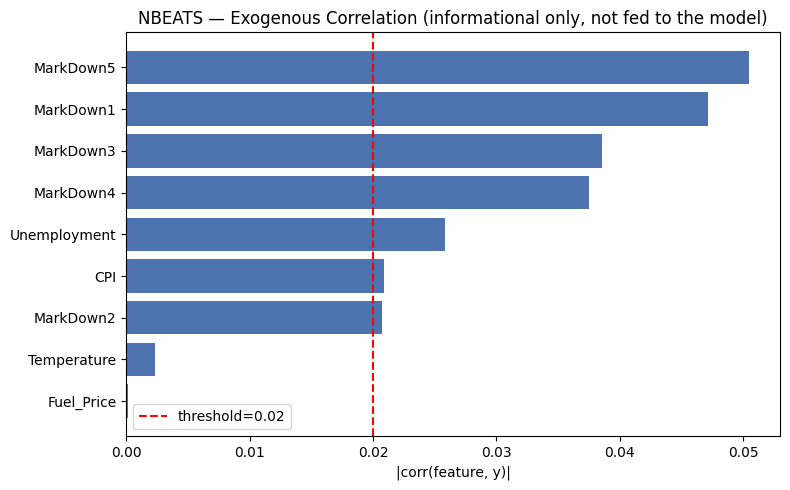

In [20]:
import matplotlib.pyplot as plt

FIGURES_DIR = "./nbeats_figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

viz_run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="visualization",
                      name=f"{MODEL_NAME}_Figures")

# 1) Feature Selection (საინფორმაციო -- არცერთი მათგანი არ ეძლევა NBEATS-ს) -- |corr(feature, y)|
sel_sorted = selection_table.sort_values("abs_corr_with_y")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(sel_sorted.index, sel_sorted["abs_corr_with_y"], color="#4C72B0")
ax.axvline(CORR_THRESHOLD, color="red", linestyle="--", label=f"threshold={CORR_THRESHOLD}")
ax.set_xlabel("|corr(feature, y)|")
ax.set_title("NBEATS — Exogenous Correlation (informational only, not fed to the model)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/nbeats_feature_selection.png", dpi=150)
wandb.log({"feature_selection": wandb.Image(fig)})
plt.show()

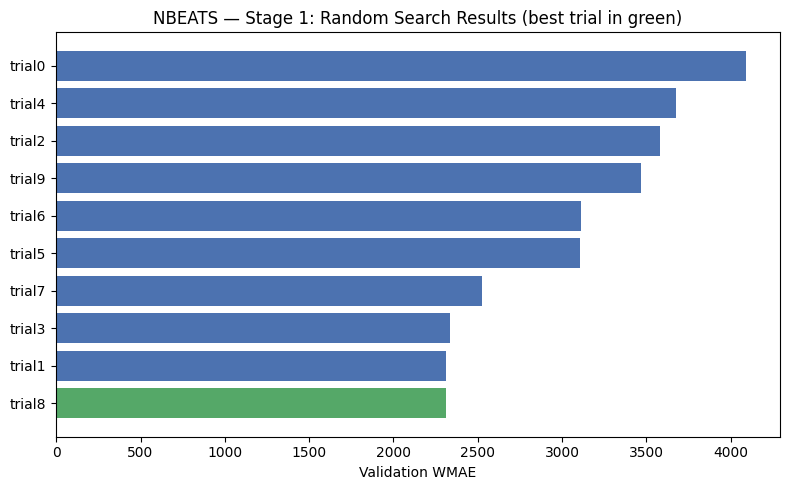

In [21]:
# 2) Stage 1 -- Random Search WMAE per trial (best highlighted)
plot_df = results_df.sort_values("val_WMAE")
colors = ["#55A868" if t == best_row["trial"] else "#4C72B0" for t in plot_df["trial"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df["trial"], plot_df["val_WMAE"], color=colors)
ax.set_xlabel("Validation WMAE")
ax.set_title("NBEATS — Stage 1: Random Search Results (best trial in green)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/nbeats_hp_search1_results.png", dpi=150)
wandb.log({"hp_search_stage1": wandb.Image(fig), "hp_search_stage1_table": wandb.Table(dataframe=results_df)})
plt.show()

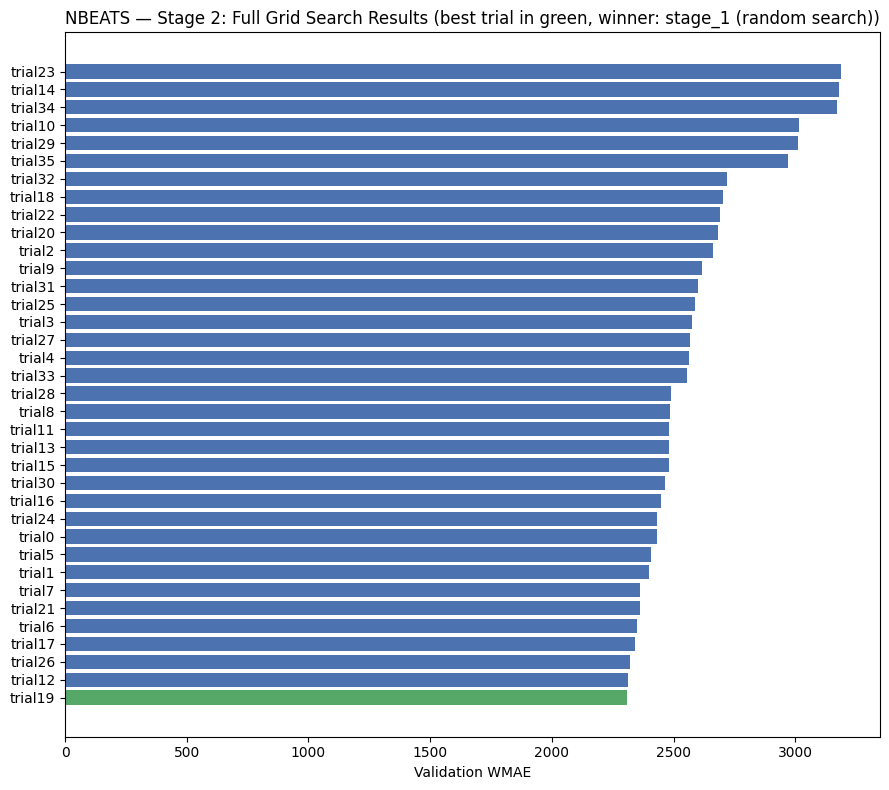

In [22]:
# 3) Stage 2 -- Full Grid Search WMAE per trial (best highlighted)
plot_df2 = results_2_df.sort_values("val_WMAE")
colors2 = ["#55A868" if t == best_row_2["trial"] else "#4C72B0" for t in plot_df2["trial"]]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(plot_df2["trial"], plot_df2["val_WMAE"], color=colors2)
ax.set_xlabel("Validation WMAE")
ax.set_title(f"NBEATS — Stage 2: Full Grid Search Results (best trial in green, winner: {winning_stage})")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/nbeats_hp_search2_results.png", dpi=150)
wandb.log({"hp_search_stage2": wandb.Image(fig), "cv_comparison": wandb.Image(fig),
           "hp_search_stage2_table": wandb.Table(dataframe=results_2_df)})
plt.show()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


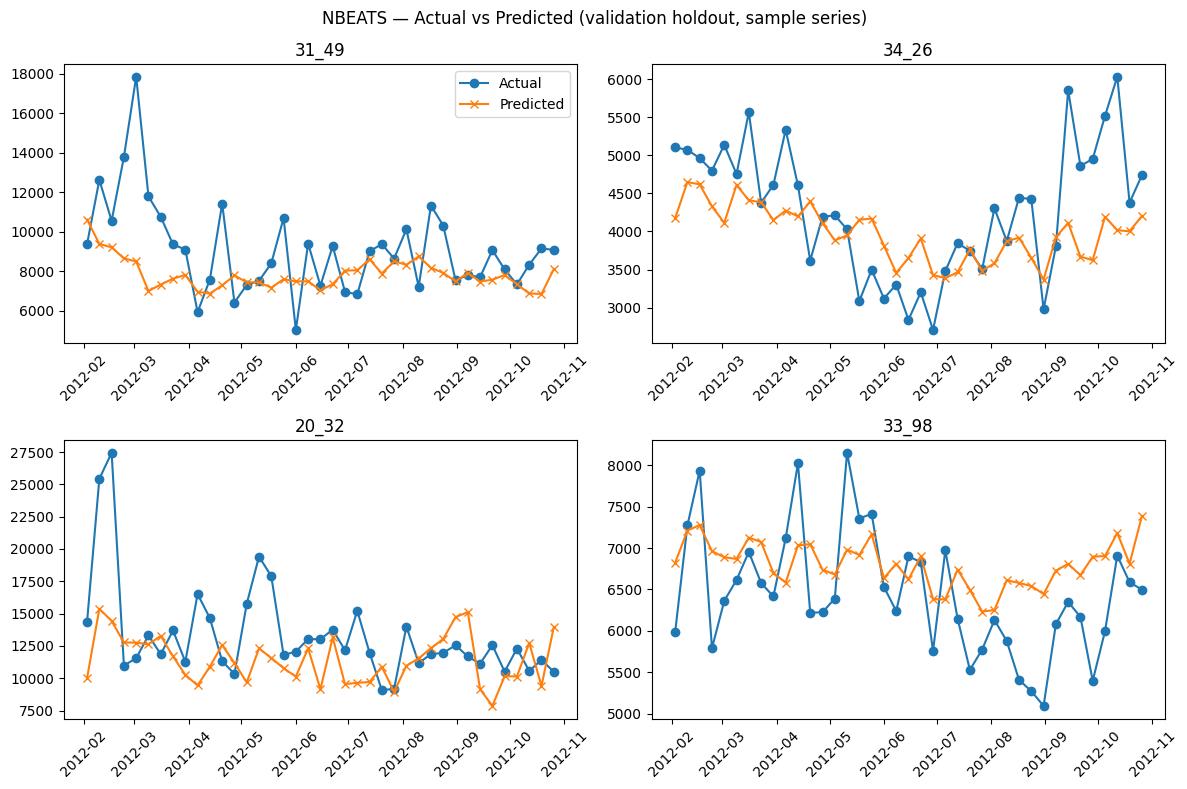

In [23]:
# nf_final-ის პროგნოზები Y_valid-ზე (holdout, არასოდეს ნანახი) -- შემდეგი ორი გრაფიკისთვის
preds_valid = nf_final.predict()  # საბაზისო NBEATS-ს futr_df არ სჭირდება
model_col = [c for c in preds_valid.columns if c not in ("unique_id", "ds")][0]
merged_valid = preds_valid.merge(Y_valid[["unique_id", "ds", "y"]], on=["unique_id", "ds"], how="inner")

# 4) Actual vs Predicted -- 4 შემთხვევით შერჩეული სერია validation window-ზე
sample_uids = merged_valid["unique_id"].drop_duplicates().sample(4, random_state=RANDOM_SEED).tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, uid in zip(axes.flat, sample_uids):
    sub = merged_valid[merged_valid["unique_id"] == uid].sort_values("ds")
    ax.plot(sub["ds"], sub["y"], label="Actual", marker="o")
    ax.plot(sub["ds"], sub[model_col], label="Predicted", marker="x")
    ax.set_title(uid)
    ax.tick_params(axis="x", rotation=45)
axes.flat[0].legend()
fig.suptitle("NBEATS — Actual vs Predicted (validation holdout, sample series)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/nbeats_actual_vs_predicted.png", dpi=150)
wandb.log({"actual_vs_predicted": wandb.Image(fig)})
plt.show()

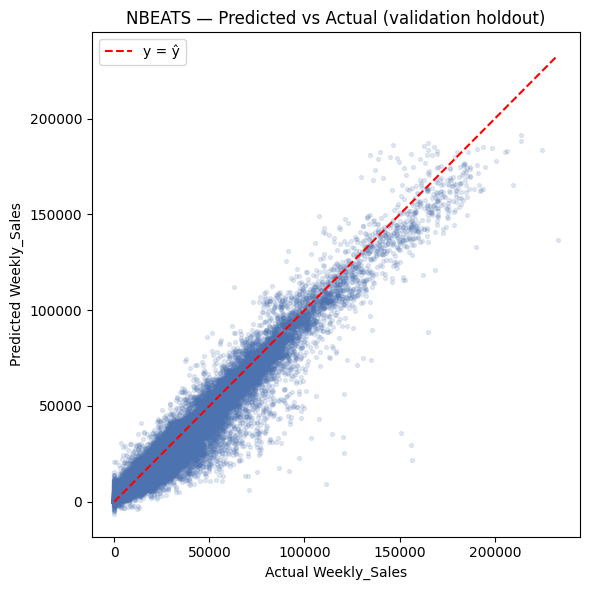

Figures saved to: /kaggle/working/nbeats_figures and logged to Wandb run: NBEATS_Figures


In [24]:
# 5) Predicted vs Actual scatter (calibration) -- მთელ validation holdout-ზე
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(merged_valid["y"], merged_valid[model_col], alpha=0.15, s=8, color="#4C72B0")
lims = [0, max(merged_valid["y"].max(), merged_valid[model_col].max())]
ax.plot(lims, lims, color="red", linestyle="--", label="y = ŷ")
ax.set_xlabel("Actual Weekly_Sales")
ax.set_ylabel("Predicted Weekly_Sales")
ax.set_title("NBEATS — Predicted vs Actual (validation holdout)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/nbeats_pred_vs_actual_scatter.png", dpi=150)
wandb.log({"pred_vs_actual_scatter": wandb.Image(fig), "holdout_diagnostics": wandb.Image(fig)})
plt.show()

viz_run.finish()
print("Figures saved to:", os.path.abspath(FIGURES_DIR), "and logged to Wandb run:", f"{MODEL_NAME}_Figures")

## 9. Full Results Summary (ტექსტური შეჯამება README-სთვის)

ყველა ეტაპის შედეგი ერთ ადგილას, ტექსტად — პირდაპირ ჩასასმელად `README.md`-ში.
ასევე ინახება `./nbeats_results_summary.txt` ფაილში.

In [25]:
import contextlib, io

def print_summary():
    print("=" * 70)
    print(f"{MODEL_NAME} — FULL RESULTS SUMMARY")
    print("=" * 70)

    print("\n--- 1. Data Cleaning ---")
    for k, v in train_stats.items():
        print(f"  train_{k}: {v}")
    for k, v in test_stats.items():
        print(f"  test_{k}: {v}")

    print("\n--- 2. Feature Engineering ---")
    print(f"  n_rows_train: {len(train_fe)}")
    print(f"  n_unique_series: {train_fe['unique_id'].nunique()}")

    print("\n--- 3. Feature Selection (informational, not fed to model) ---")
    print(selection_table.to_string())
    print(f"  selected (corr>={CORR_THRESHOLD}, missing<{MISSING_THRESHOLD}): {selected}")

    print("\n--- 4. Train/Valid Split ---")
    print(f"  cutoff_date: {cutoff_date.date()}")
    print(f"  n_series (valid_ids): {len(valid_ids)}")
    print(f"  train rows: {len(Y_train)} | valid rows: {len(Y_valid)}")

    print("\n--- 5. Hyperparameter Search -- Stage 1 (Random Search, 10 trials) ---")
    print(results_df.to_string(index=False))
    print(f"\n  Stage 1 best: {best_row['trial']} | val_WMAE={best_row['val_WMAE']:.2f} | val_MAE={best_row['val_MAE']:.2f}")

    print("\n--- 5b. Hyperparameter Search -- Stage 2 (Full Grid Search, "
          f"{len(configs_2)} trials) ---")
    print(results_2_df.to_string(index=False))
    print(f"\n  Stage 2 best: {best_row_2['trial']} | val_WMAE={best_row_2['val_WMAE']:.2f} | val_MAE={best_row_2['val_MAE']:.2f}")

    print(f"\n  WINNING STAGE: {winning_stage}")
    print(f"  FINAL best_cfg: {best_cfg}")

    print("\n--- 6. Final Training (best_cfg, full Y_train) ---")
    print(f"  final_wmae (holdout, 39-week): {final_wmae:.2f}")
    print(f"  final_mae  (holdout, 39-week): {final_mae:.2f}")

    print("\n--- 7. Deploy Refit (best_cfg, full history nf_df) ---")
    print(f"  max train date used: {nf_df['ds'].max().date()}")
    print(f"  pipeline saved to: {PIPELINE_DIR}")

    print("\n--- 8. Pipeline Preview (raw test.csv -> predictions, with fallback) ---")
    print(f"  shape: {preds_preview.shape}")
    print(preds_preview.head(10).to_string(index=False))

    print("\n--- 9. Wandb Registry ---")
    print(f"  artifact name: {MODEL_NAME}_pipeline")
    print(f"  registry target: wandb-registry-model/{MODEL_NAME}")

    print("\n" + "=" * 70)
    print("END OF SUMMARY")
    print("=" * 70)

print_summary()

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    print_summary()
summary_text = buf.getvalue()
with open("./nbeats_results_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)
print(f"\nSaved to ./nbeats_results_summary.txt ({len(summary_text)} chars)")

NBEATS — FULL RESULTS SUMMARY

--- 1. Data Cleaning ---
  train_rows_before: 421570
  train_rows_after: 421570
  train_duplicates_removed: 0
  train_negative_sales_clipped: 1285
  train_markdown_na_filled: 1422431
  test_rows_before: 115064
  test_rows_after: 115064
  test_duplicates_removed: 0
  test_negative_sales_clipped: 0
  test_markdown_na_filled: 51493

--- 2. Feature Engineering ---
  n_rows_train: 421570
  n_unique_series: 3331

--- 3. Feature Selection (informational, not fed to model) ---
              abs_corr_with_y  missing_rate
MarkDown5            0.050465           0.0
MarkDown1            0.047172           0.0
MarkDown3            0.038562           0.0
MarkDown4            0.037467           0.0
Unemployment         0.025860           0.0
CPI                  0.020923           0.0
MarkDown2            0.020720           0.0
Temperature          0.002312           0.0
Fuel_Price           0.000121           0.0
  selected (corr>=0.02, missing<0.5): ['MarkDown5', 'Ma

## შედეგი

`final_wmae` არის ის რიცხვი, რომელიც ამ notebook-იდან შედარდება დანარჩენი
არქიტექტურების (ARIMA/SARIMA/XGBoost/LightGBM/TFT/...) `val_WMAE`-ს — ყველაზე
დაბალი WMAE იგებს. საბოლოო `best_cfg` არჩეულია **ორსაფეხურიანი HP search-ით**
(Stage 1: random search 36-დან 10 კონფიგურაცია; Stage 2: სრული ფაქტორული grid
search დაზუსტებულ `input_size`-ის დიაპაზონში + `stack_arch`/`learning_rate`/
`batch_size`-ის ურთიერთქმედების სრული შემოწმება). `NBEATSPipeline`
(deployment-ზე refit-ული მოდელით, `nf_deploy`, **fallback-ით** NBEATS-ისთვის
უცნობი სერიებისთვის) დარეგისტრირებულია Wandb Registry-ში და მზადაა raw test
set-ზე submission-ის დასაგენერირებლად. `./nbeats_figures/`-ში შენახული 5 PNG
(ასევე დალოგილი Wandb-ში, `{MODEL_NAME}_Figures` run-ის ქვეშ, `wandb.Image`
საშუალებით) და `./nbeats_results_summary.txt` README.md-ში ჩასასმელად მზადაა.